##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import numpy as np
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping

seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [2]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar

--2026-04-19 18:22:14--  https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1045106394 (997M) [application/x-rar-compressed]
Saving to: ‘UCF11_updated_mpg.rar’

UCF11_updated_mpg.r 100%[===================>] 996.69M  47.4MB/s    in 23s     

2026-04-19 18:22:37 (44.0 MB/s) - ‘UCF11_updated_mpg.rar’ saved [1045106394/1045106394]



In [3]:
!unrar x UCF11_updated_mpg.rar -y -inul

In [4]:
!ls

sample_data  UCF11_updated_mpg	UCF11_updated_mpg.rar


In [5]:
!ls UCF11_updated_mpg

basketball  golf_swing	     swing		 volleyball_spiking
biking	    horse_riding     tennis_swing	 walking
diving	    soccer_juggling  trampoline_jumping


In [6]:
image_height, image_width = 64, 64
max_images_per_class = 800

dataset_directory = "UCF11_updated_mpg"

classes_list = [
    "basketball",
    "biking",
    "tennis_swing"
]

model_output_size = len(classes_list)

In [7]:
def frames_extraction(video_path):
    frames_list = []

    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break

        frame = cv2.resize(frame, (image_width, image_height))
        frame = frame / 255.0

        frames_list.append(frame)

    video_reader.release()
    return frames_list

In [8]:
def create_dataset():
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print("Processing:", class_name)

        class_path = os.path.join(dataset_directory, class_name)

        temp_frames = []

        for root, dirs, files in os.walk(class_path):
            for file in files:
                if file.endswith(".mpg"):
                    video_path = os.path.join(root, file)

                    frames = frames_extraction(video_path)
                    temp_frames.extend(frames)

        temp_frames = random.sample(temp_frames, max_images_per_class)

        features.extend(temp_frames)
        labels.extend([class_index] * max_images_per_class)

    return np.array(features), np.array(labels)

In [9]:
features, labels = create_dataset()

labels = to_categorical(labels, num_classes=model_output_size)

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

Processing: basketball
Processing: biking
Processing: tennis_swing
Features shape: (2400, 64, 64, 3)
Labels shape: (2400, 3)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant
)

In [11]:
def create_model():
    model = Sequential()

    model.add(Conv2D(64, (3,3), activation='relu',
                     input_shape=(image_height, image_width, 3)))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(model_output_size, activation='softmax'))

    model.summary()
    return model

model = create_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8939 - loss: 0.2721 - val_accuracy: 0.8568 - val_loss: 0.4903
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9180 - loss: 0.2326 - val_accuracy: 0.8984 - val_loss: 0.2798
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9349 - loss: 0.1961 - val_accuracy: 0.9115 - val_loss: 0.2015
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9212 - loss: 0.2275 - val_accuracy: 0.5469 - val_loss: 1.4837
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9316 - loss: 0.1886 - val_accuracy: 0.8750 - val_loss: 0.3787
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9505 - loss: 0.1588 - val_accuracy: 0.9141 - val_loss: 0.2061
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9596 - loss: 0.1285 - val_accuracy: 0.7891 - val_loss: 0.7955
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9648 - loss: 0.1131 - val_accuracy: 0.

In [15]:
model.evaluate(X_test, y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9646 - loss: 0.1164


[0.11636392027139664, 0.9645833373069763]

In [16]:
student_name = "JanaAlanazy"
save_path = f"{student_name}_UCF11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

Model saved as JanaAlanazy_UCF11_model.h5


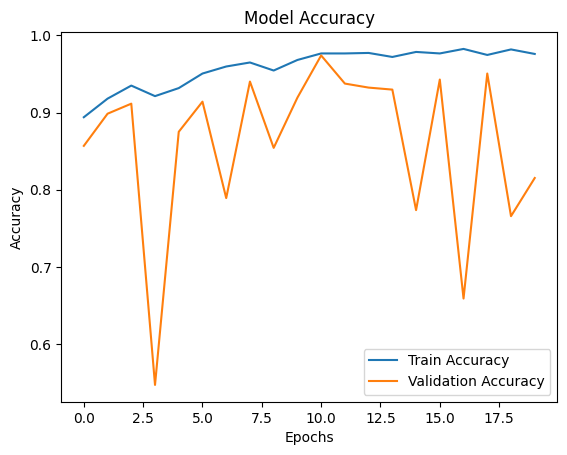

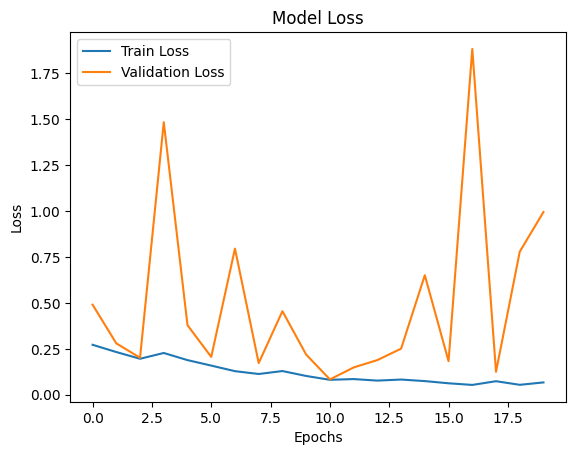

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
from google.colab import files

uploaded = files.upload()

Saving basketball.mp4 to basketball.mp4


In [21]:
from google.colab import files

uploaded = files.upload()

Saving biking.mp4 to biking.mp4


In [22]:
from google.colab import files

uploaded = files.upload()

Saving tennis.mp4 to tennis.mp4


In [23]:
import os

print(os.listdir("/content"))

['.config', 'biking.mp4', 'JanaAlanazy_UCF11_model.h5', 'tennis.mp4', 'UCF11_updated_mpg', 'UCF11_updated_mpg.rar', 'basketball.mp4', 'sample_data']


In [25]:
import cv2
import numpy as np
import random

classes_list = ["basketball", "biking", "tennis_swing"]

def frames_extraction(video_path):
    frames = []

    cap = cv2.VideoCapture(video_path)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (64, 64))
        frame = frame / 255.0

        frames.append(frame)

    cap.release()
    return frames


def predict_video(video_path):
    frames = frames_extraction(video_path)

    if len(frames) == 0:
        return "No frames extracted"

    frames = np.array(frames)

    sample = random.sample(list(frames), min(10, len(frames)))

    preds = []

    for f in sample:
        f = np.expand_dims(f, axis=0)
        preds.append(model.predict(f, verbose=0))

    avg_pred = np.mean(preds, axis=0)

    return classes_list[np.argmax(avg_pred)]

In [26]:
from tensorflow.keras.models import load_model

model = load_model("JanaAlanazy_UCF11_model.h5")
print("Model loaded")

Model loaded


In [27]:
video_paths = [
    "/content/basketball.mp4",
    "/content/biking.mp4",
    "/content/tennis.mp4"
]

for video_path in video_paths:
    print("\n====================")
    print("Path:", video_path)

    result = predict_video(video_path)

    print("Prediction:", result)


Path: /content/basketball.mp4
Prediction: basketball

Path: /content/biking.mp4
Prediction: biking

Path: /content/tennis.mp4
Prediction: tennis_swing
